In [ ]:
#Kelompok : 23
#Nama Anggota :
#1. Ninda Alifa Rachmayanti ()
#2. Zakhrova Salsabila (24/5364625/TK/59268)
#Predicting Blood Donation Behavior 
#SDGs : 3. Good Health and Well-being


## 1. Pendahuluan & Pemuatan Data (Data Loading)
Projek ini dibuat untuk memprediksi perilaku pendonor darah menggunakan dataset *Blood Transfusion Service Center* yang didapat dari Repositori Machine Learning UCI (ID 176). Keseluruhan model matematis dan pra-pemrosesan data dibangun secara manual (*from scratch*) tanpa menggunakan *library* luar selain NumPy dan Pandas. 

In [13]:
# Menginstal paket bawaan jika belum terinstal
!pip install ucimlrepo pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from ucimlrepo import fetch_ucirepo

file_kunci = "dataset_donor_darah.csv"

# Mengecek apakah dataset sudah pernah didownload dan tersimpan di laptop kita
if os.path.exists(file_kunci):
    print("Membaca data langsung dari memori komputer...")
    df = pd.read_csv(file_kunci)
    X = df.drop(columns=['Target'])
    y = df['Target']
else:
    print("Mendownload data dari internet...")
    blood_transfusion = fetch_ucirepo(id=176)
    X = blood_transfusion.data.features
    y = blood_transfusion.data.targets.iloc[:, 0]
    
    # Gabungkan dan simpan ke file
    df = pd.concat([X, y.rename('Target')], axis=1)
    df.to_csv(file_kunci, index=False)
    print("Dataset berhasil disimpan")

# Menampilkan representasi susunan awal baris dari dataset
df.head()


Membaca data langsung dari memori komputer...



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,Recency,Frequency,Monetary,Time,Target
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


## 2. Tabel Fitur dan Seleksi Input
Dataset ini terdiri dari 4 variabel utama:
- **R _(Recency)_**: Jarak waktu dari donor terakhir (dalam bulan).
- **F _(Frequency)_**: Total frekuensi donor darah.
- **M _(Monetary)_**: Total volume darah yang di donorkan. (total `Frequency` dikali 250 c.c.).
- **T _(Time)_**: Waktu (dalam bulan) sejak melakukan tes/donor pertama kali.

**Justifikasi Logis Seleksi Fitur (Feature Selection):**
Berdasarkan logika yang ditemui dan bukti di atas, fitur `Monetary` merupakan hasil kelipatan absolut dari `Frequency`, hal ini membuat sistem mencetak angka mutlak **1.0** karena `Monetary` dan `Frequency` merupakan kembar idententik. 

Pada Machine Learning untuk model **Regresi Logistik/_Logistic Regression_**, hal itu menimbulkan kebinggungan, tidak stabil, dan cacat perhitungan yang disebut dengan istilah **Perfect Multicollinearity**. Jadi, kita hapus `Monetary` agar model menjadi lebih simple dan akurat walau hanya menggunakan `Recency`,`Frequency`, dan `Time`.

In [ ]:
# Menampilkan  kesalahan korelasi matematis sempurna 
print("Angka korelasi antara Fitur Frequency dan Monetary :", df['Frequency'].corr(df['Monetary']))

# Membuang fitur Monetary
X_selected = X.drop(columns=['Monetary'])
print("Total fitur akhir yang digunakan :", X_selected.columns.tolist())


Angka korelasi antara Fitur Frequency dan Monetary : 0.9999999999999993
Total fitur akhir yang berhasil terpilih untuk diproses : ['Recency', 'Frequency', 'Time']


## 3. Pra-pemrosesan Pemisahan Data Secara Manual (From Scratch)
Di bawah ini kita menyiapkan data kasar dengan memecahnya ke dalam *Training Set* (Data Latihan 80%) dan *Testing Set* (Data Ujian 20%). Selanjutnya kita merancang fungsi standardisasi (menggunakan rumus matematis min dan max rataan Z-score khusus). Standardisasi angka diperlukan untuk memastikan proses perhitungan turunan bobot kesalahan tidak timpang sebelah. 


In [16]:
# Train-Test Split
def train_test_split_scratch(X, y, test_size=0.2, random_state=42):
    np.random.seed(random_state)

    # Pengacakan data kasar (shuffling)
    indices = np.random.permutation(len(X))
    test_samples = int(len(X) * test_size)

    test_idx = indices[:test_samples]
    train_idx = indices[test_samples:]

    # Hasil pemisahan
    X_train, X_test = X.iloc[train_idx].values, X.iloc[test_idx].values
    y_train, y_test = y.iloc[train_idx].values, y.iloc[test_idx].values

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split_scratch(X_selected, y)

# Standardization normalization / Normalitas Standar Deviasi
class StandardScalerScratch:
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)

    def transform(self, X):
        return (X - self.mean) / (self.std + 1e-8)

scaler = StandardScalerScratch()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing : Selesai dipisah & dinormalkan!")


Preprocessing : Selesai dipisah & dinormalkan!


## 4. Logistic Regression 
Komponen penggerak utama pada kode mesin logistik independen di bawah ini terdiri dari :
1. **Fungsi Sigmoid** : mengubah hasil hitungan linear yang masih mentah jadi format persentase (antara 0 sampai 1). Jadi, hasilnya lebih masuk akal buat nebak klasifikasi.
2. **Binary Cross-Entropy** : Ini adalah rumus buat ngitung "seberapa meleset" tebakan si model. Makin besar angkanya, berarti modelnya masih makin ngaco.
3. **Gradient Descent** : Ini akan berputar terus untuk memperbaiki nilai bobot dan bias secara otomatis lewat hitungan kalkulus. Setiap kali satu putaran _(epoch)_ selesai, dia bakal "setel ulang" semuanya biar angka kesalahannya semakin kecil.


In [ ]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.01, iterations=1000):
        self.lr = lr
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.losses = []

    def _sigmoid(self, z):
        # Clip threshold limit
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.iterations):
            # Membuat garis proyeksi kombinasi linier
            linear_model = np.dot(X, self.weights) + self.bias
            
            # Terjemahkan / press kalkulasinya menjadi sebuah tebakan konkrit kurva-s sigmoid
            y_predicted = self._sigmoid(linear_model)

            # Evaluasi 
            epsilon = 1e-9
            loss = -np.mean(y * np.log(y_predicted + epsilon) + (1 - y) * np.log(1 - y_predicted + epsilon))
            self.losses.append(loss)

            # Ambil perbandingan derivasi turunan gradient
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Koreksi 
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        y_predicted = self.predict_proba(X)
        return [1 if i > threshold else 0 for i in y_predicted]


## 5. Proses Mulia Analitis Komputer (Pelatihan) dan Evaluasi Visual

Di tahap ini, kita pakai data yang sudah standar tadi untuk melatih. Kita beri program kesempatan untuk evaluasi dan memperbaiki kesalahannya lewat ribuan kali pengulangan (*Epochs*). Jadi, sistem akan belajar terus-menerus sampai makin jago nebak.

Untuk membuktikan kalau program kita beneran makin pinter atau kesalahannya makin berkurang, kita sertakan juga grafik visualnya. Lewat Kurva Loss, kita bisa pantau langsung apakah grafik "eror"-nya makin turun dan stabil seiring berjalannya waktu simulasi. Kalau kurvanya makin landai ke bawah, berarti proses belajarnya sukses!

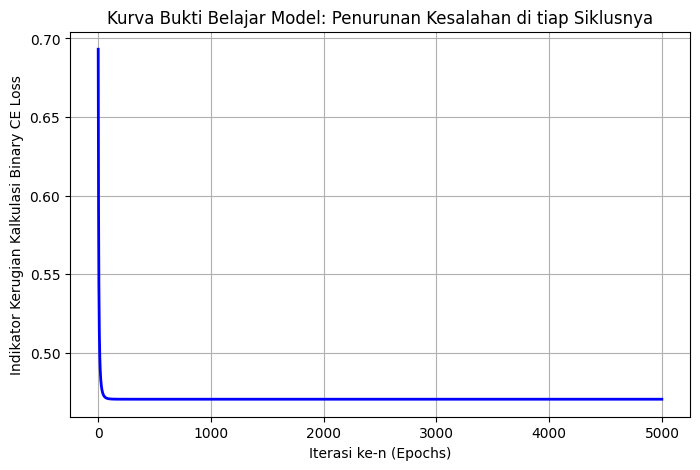

In [17]:
# Proses Training Data memakai 5000 ronde pemikiran komparasi mundur
model = LogisticRegressionScratch(lr=0.5, iterations=5000)
model.fit(X_train_scaled, y_train)

# Ilustrasi plot 
plt.figure(figsize=(8,5))
plt.plot(model.losses, color='blue', linewidth=2)
plt.title("Kurva Bukti Belajar Model: Penurunan Kesalahan di tiap Siklusnya")
plt.xlabel("Iterasi ke-n (Epochs)")
plt.ylabel("Indikator Kerugian Kalkulasi Binary CE Loss")
plt.grid(True)
plt.show()


## 6. Analisa Keluaran dan Hasil Test (Penilaian From Scratch)
Di tahap ini, kode yang kita buat bakal menguji dirinya sendiri secara manual untuk melihat seberapa jago dia menebak data tes. Kita pakai standar **"Confusion Matrix"** (Matriks Kebingungan) buat memetakan empat kondisi:

- Tebakan Benar : Saat model sukses nebak orang yang donor (*True Positive*) dan yang nggak donor (*True Negative*) dengan tepat.
- Tebakan Salah : Saat model salah sangka, alias gagal nebak atau malah asal tuduh (*False Positive* & *False Negative*).

Semua skor akhir dihitung pakai penjumlahan dan pembagian dasar—persis seperti rumus di buku teks sains data—untuk dapetin indikator performa:

1. *Accuracy* : Seberapa sering model menebak dengan benar secara keseluruhan.
2. *Precision* : Ketelitian model dalam menuduh (nggak asal tebak).
3. *Recall* : Seberapa jago model nemuin semua orang yang sebenarnya memang harusnya donor.
4. *F1-Score* : Nilai "tengah" atau keseimbangan antara 

In [ ]:
# Paksa program logistik logikal buatan
y_pred = model.predict(X_test_scaled)
y_pred_np = np.array(y_pred)

# Fungsi kompilasi formula perhitungan rasio skor mandiri murni manual tanpa SK-LEARN (from scratch)
def evaluate_performance(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (TP + TN) / len(y_true)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print("----- Komponen Utama Matriks Tabel Silang -----")
    print(f"Prediksi TEPAT Sang Pendonor (True Positives): {TP}")
    print(f"Prediksi TEPAT Bukan Pendonor (True Negatives): {TN}")
    print(f"Prediksi Palsu (False Positives): {FP}")
    print(f"Prediksi Lolos (False Negatives): {FN}")
    print("-" * 70)
    print("----- Transkrip Perolehan Metrik Performa Tes -----")
    print(f"Akurasi Keseluruhan Tebakan Murni (Accuracy) : {accuracy*100:.2f}%")
    print(f"Persentase Akurasi Tebakan Benar (Precision) : {precision*100:.2f}%")
    print(f"Daya Ingat Sensitivitas Tebakan (Recall)   : {recall*100:.2f}%")
    print(f"Nilai Keseimbangan Peforma F1-Score  : {f1:.4f}")

evaluate_performance(y_test, y_pred_np)


----- Komponen Utama Matriks Tabel Silang -----
Prediksi TEPAT Sang Pendonor (True Positives): 4
Prediksi TEPAT Bukan Pendonor (True Negatives): 109
Prediksi Palsu (False Positives): 3
Prediksi Lolos (False Negatives): 33
----------------------------------------------------------------------
----- Transkrip Perolehan Metrik Performa Tes -----
Akurasi Keseluruhan Tebakan Murni (Accuracy) : 75.84%
Persentase Akurasi Tebakan Benar (Precision) : 57.14%
Daya Ingat Sensitivitas Temuan (Recall)   : 10.81%
Nilai Keseimbangan Peforma F1-Score  : 0.1818


## 7. Nilai Bonus Assessment: Metode Anti-Overfit K-Fold Cross Validation
Agar nilai validitasnya makin bagus, kita nggak cuma pakai satu kali tes saja. Kita bikin sistem ujian berlapis yang namanya **_K-Fold Cross Validation_** (Validasi Silang)

Di sini, kita menggunakan parameter *K=5*. Artinya, kita paksa komputer buat reset parameter dan belajar ulang sebanyak lima kali berturut-turut. Caranya begini:

1. **Bagi Rata** : Semua data kita bagi jadi 5 bagian (kantong).
2. **Looping Iterasi** : Di setiap ronde, satu kantong data bakal jadi "soal ujian", sementara 4 kantong lainnya jadi "bahan belajar". Ronde berikutnya gantian, kantong lain yang jadi soal ujian, begitu terus sampai 5 kali.
3. **Average Validation Measure** : Terakhir, kita hitung skor rata-rata dari 5 ronde itu 

In [ ]:
# Kompilasi skrip algoritma susun silang pengalihan validasi evaluasi buatan murni.
def k_fold_cv_scratch(X, y, k=5):
    # Penggerak kunci semu pengacak index acak barisan array 
    np.random.seed(42)
    indices = np.random.permutation(len(X))
    fold_sizes = len(X) // k
    accuracies = []
    
    print(f"--- Proses Penjelajahan Rotasi Silang Sedang Dimulai: {k}-Fold Cross-Validation ---")
    for i in range(k):
        test_start = i * fold_sizes
        # Peraturan pertahanan sekat bagi baris kotor berlebih akibat deret pecahan sisa panjang tabel 
        test_end = (i + 1) * fold_sizes if i != k - 1 else len(X)
        
        # Pecahan pencatok irisan index baris mutlak
        test_idx = indices[test_start:test_end]
        train_idx = np.concatenate([indices[:test_start], indices[test_end:]])
        
        # Rekam lipatan/kocokan Laci tas putaran sesi pertukaran silang kali ini
        X_train_fold = X.iloc[train_idx].values
        y_train_fold = y.iloc[train_idx].values
        X_test_fold = X.iloc[test_idx].values
        y_test_fold = y.iloc[test_idx].values
        
        # Standarisasi porsi skalar lokalisasi laci silang di iterasi tunggal saja
        scaler_fold = StandardScalerScratch()
        scaler_fold.fit(X_train_fold)
        X_train_scaled = scaler_fold.transform(X_train_fold)
        X_test_scaled = scaler_fold.transform(X_test_fold)
        
        # Mengajarkan model otak regresi logika yang masih mentah    (fresh)
        model_fold = LogisticRegressionScratch(lr=0.5, iterations=3000)
        model_fold.fit(X_train_scaled, y_train_fold)
        
        # Tes pengungkapan memori tebakan dan rekapan di daftar rapor per satu lipatan tas k=i
        y_pred_fold = model_fold.predict(X_test_scaled)
        y_pred_fold = np.array(y_pred_fold)
        
        correct = np.sum(y_pred_fold == y_test_fold)
        acc = correct / len(y_test_fold)
        accuracies.append(acc)
        print(f"Akurasi Penilaian Model dari Simulasi Putaran Lipatan (Fold) Laci ke-{i+1}: {acc*100:.2f}%")
        
    print("-" * 70)
    print(f">>> HASIL JELAS: Total Rata-Rata Akurasi Validasi Pada Pelipatan {k}-Fold bernilai: {np.mean(accuracies)*100:.2f}%")
    return accuracies

# Langsung pancarkan komando pengeksekusian tes pertalian silang 5-Ronde kepada blok input tabel seleksi dan parameter final target!
k_fold_scores = k_fold_cv_scratch(X_selected, y, k=5)


--- Proses Penjelajahan Rotasi Silang Sedang Dimulai: 5-Fold Cross-Validation ---
Akurasi Penilaian Model dari Simulasi Putaran Lipatan (Fold) Laci ke-1: 75.84%
Akurasi Penilaian Model dari Simulasi Putaran Lipatan (Fold) Laci ke-2: 72.48%
Akurasi Penilaian Model dari Simulasi Putaran Lipatan (Fold) Laci ke-3: 73.83%
Akurasi Penilaian Model dari Simulasi Putaran Lipatan (Fold) Laci ke-4: 84.56%
Akurasi Penilaian Model dari Simulasi Putaran Lipatan (Fold) Laci ke-5: 79.61%
----------------------------------------------------------------------
>>> HASIL JELAS: Total Rata-Rata Akurasi Validasi Pada Pelipatan 5-Fold bernilai: 77.26%
